In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import os
import cv2
import shutil
import zipfile
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.metrics import auc, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import random
from PIL import Image

In [2]:
# Open the folder to view files
# Define paths
zip_path = "/content/PlantVillage.zip"
extract_to = "dataset"

# 1. Extract the zip file
print("Extracting archive...")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

# 2. Define the path to the internal plant village folder and target folders
plant_village_path = os.path.join(extract_to, "PlantVillage")
folders_to_keep = [
    "PotatoEarlyblight",
    "PotatoLateblight",
    "Potatohealthy",
]

# 3. Move the target folders up to the main 'dataset' root
print("Moving potato folders...")
for folder in folders_to_keep:
    source_folder = os.path.join(plant_village_path, folder)
    destination_folder = os.path.join(extract_to, folder)

    if os.path.exists(source_folder):
        shutil.move(source_folder, destination_folder)
    else:
        print(f"Warning: Could not find {folder} inside 'plant village'")

# 4. Remove the now-empty 'plant village' folder
if os.path.exists(plant_village_path):
    print("Removing empty 'plant village' folder...")
    shutil.rmtree(plant_village_path)

print("Done! dataset is ready in the 'dataset/' directory.")



Extracting archive...
Moving potato folders...
Removing empty 'plant village' folder...
Done! dataset is ready in the 'dataset/' directory.


--- Dataset Analysis ---
Class 'PotatoEarlyblight': 1000 images
Class 'PotatoLateblight': 1000 images
Class 'Potatohealthy': 152 images
Total dataset size: 2152 images

Sample image resolutions (Width, Height): {(256, 256)}


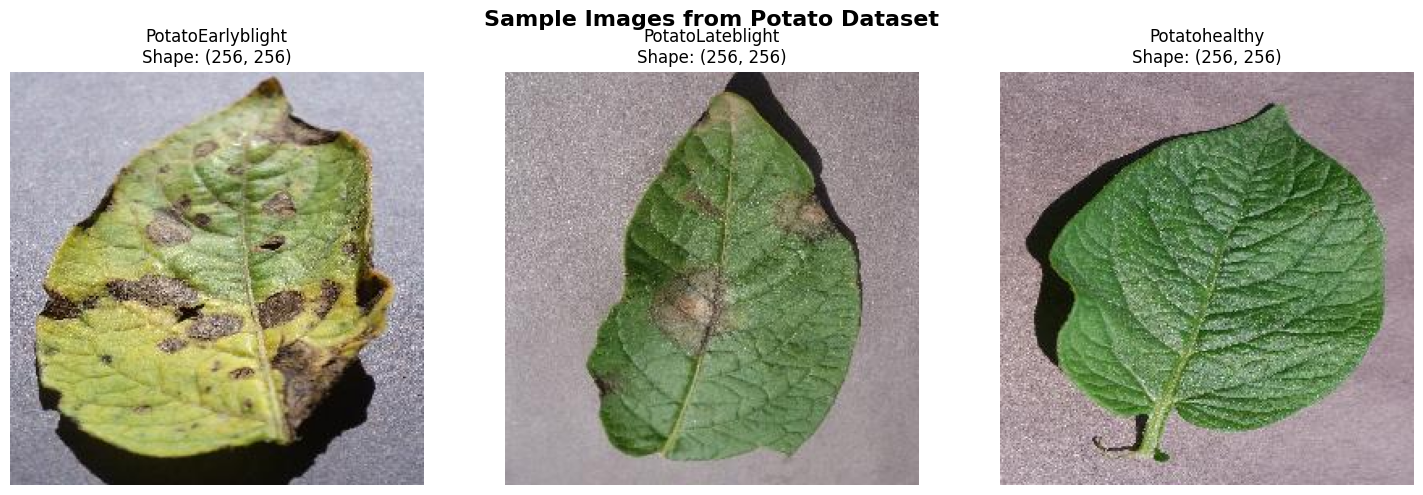

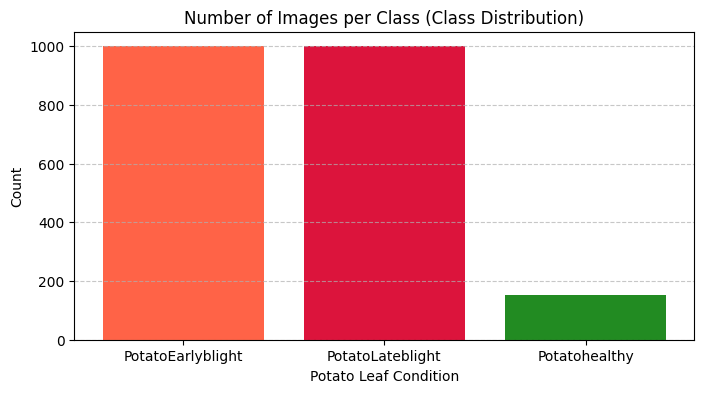

In [3]:
# Preliminary data analysis
# Define dataset directory
dataset_dir = "dataset"
classes = ["PotatoEarlyblight",
           "PotatoLateblight",
           "Potatohealthy"]

# 1. DATA ANALYSIS: Check Dataset Balance

print("--- Dataset Analysis ---")
total_images = 0
class_counts = {}

for c in classes:
    class_path = os.path.join(dataset_dir, c)
    if os.path.exists(class_path):
        # List all valid image files
        images = [
            f
            for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[c] = len(images)
        total_images += len(images)
        print(f"Class '{c}': {len(images)} images")
    else:
        print(f"Directory not found: {class_path}")

print(f"Total dataset size: {total_images} images\n")

# Check resolutions of a few random images to understand sizing
sample_sizes = []
for c in classes:
    class_path = os.path.join(dataset_dir, c)
    images = os.listdir(class_path)
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        with Image.open(img_path) as img:
            sample_sizes.append(img.size)
print(f"Sample image resolutions (Width, Height): {set(sample_sizes)}")


# 2. VISUALIZATION: View Sample Photos

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Sample Images from Potato Dataset", fontsize=16, weight="bold")

for i, c in enumerate(classes):
    class_path = os.path.join(dataset_dir, c)
    images = os.listdir(class_path)

    # Pick a random image from the folder
    random_img_name = random.choice(images)
    img_path = os.path.join(class_path, random_img_name)

    # Load and display the image
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{c}\nShape: {img.size}", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# 3. ANALYSIS: Plot Class Distribution

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color=["tomato", "crimson", "forestgreen"])
plt.title("Number of Images per Class (Class Distribution)")
plt.xlabel("Potato Leaf Condition")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [4]:
# Data preprocessing
# Define constants
DATASET_DIR = "dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# 1. Load Datasets cleanly

print("Loading base splits...")
train_ds_initial = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds_initial = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

# Store class names before transformations make them inaccessible
GLOBAL_CLASS_NAMES = train_ds_initial.class_names
num_classes = len(GLOBAL_CLASS_NAMES)

# Apply transformations to the datasets
train_ds = train_ds_initial
val_ds = val_ds_initial

# Formal 80/10/10 Split
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)


# 2. Compute Class Weights to balance the loss function

# Extract all the integer labels from the training dataset to evaluate distribution
print("Calculating class weights based on true training data balance...")
y_train = np.concatenate([y for x, y in train_ds], axis=0)
classes_present = np.unique(y_train)

# Calculate weights using scikit-learn logic: total_samples / (n_classes * class_samples)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

# Convert to a dictionary format Keras requires: {0: weight_0, 1: weight_1, 2: weight_2}
class_weight_dict = dict(zip(classes_present, class_weights_array))

print("\n--- Calculated Imbalance Adjustments ---")
for idx, name in enumerate(GLOBAL_CLASS_NAMES):
    print(f"Class '{name}' -> Weight Penalty: {class_weight_dict[idx]:.4f}")


# 3. Define the Augmentation Sequential Model

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(factor=0.2, fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomZoom(height_factor=0.15, width_factor=0.15, fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomContrast(factor=0.15, seed=SEED)
])

# 4. Map Augmentation to Training Dataset & Prefetch

AUTOTUNE = tf.data.AUTOTUNE
# Apply data_augmentation ONLY to training data
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# Pipeline performance configurations
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Augmented data pipelines and balancing profiles successfully mounted!")

Loading base splits...
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Calculating class weights based on true training data balance...

--- Calculated Imbalance Adjustments ---
Class 'PotatoEarlyblight' -> Weight Penalty: 0.7017
Class 'PotatoLateblight' -> Weight Penalty: 0.7247
Class 'Potatohealthy' -> Weight Penalty: 5.1250
Augmented data pipelines and balancing profiles successfully mounted!


In [5]:
# Model Architecture
# MODEL 1: MobileNetV2 Architecture

print("Initializing MobileNetV2...")
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
mobilenet_base.trainable = False  # Freeze pre-trained weights

mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    # Apply MobileNetV2 specific scaling ([0, 255] -> [-1, 1])
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="MobileNetV2_Pipeline")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# MODEL2: MobileNetV3 Architecture
print("Initializing MobileNetV3Large...")
mobilenetv3_base = tf.keras.applications.MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
mobilenetv3_base.trainable = False  # Freeze pre-trained weights

mobilenetv3_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
    mobilenetv3_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="MobileNetV3_Pipeline")

mobilenetv3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Initializing MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Initializing MobileNetV3Large...
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Create a folder to store the trained weight snapshots
os.makedirs("saved_models", exist_ok=True)

def get_callbacks(model_name):
    """Generates structural production callbacks tailored to each model architecture."""
    return [
        # 1. Early Stopping: Halts execution if validation loss stops improving for 5 epochs
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        # 2. Model Checkpoint: Saves only the mathematically best version of the weights
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'saved_models/{model_name}_best.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),

        # 3. Reduce Learning Rate on Plateau: Drops learning rate by a factor of 0.2
        # if val_loss is flat for 2 epochs. Helps settle the model into global minima.
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]


In [7]:
# Model training

EPOCHS = 20
# TRAINING 1: Train the MobileNetV2 Pipeline

print("\n=== STARTING MOBILENETV2 TRAINING ===")
mobilenet2_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("mobilenetv2")
)

# TRAINING 2: Train the MobileNetV3 Pipeline

print("\n=== STARTING MobileNetV3 TRAINING ===")
monbilenet3_history = mobilenetv3_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("mobilenetv3")
)

print("\n Training Complete! Best weights are saved in 'saved_models/' directory.")


=== STARTING MOBILENETV2 TRAINING ===
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.6902 - loss: 0.8196
Epoch 1: val_loss improved from None to 0.15885, saving model to saved_models/mobilenetv2_best.keras

Epoch 1: finished saving model to saved_models/mobilenetv2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 69s 591ms/step - accuracy: 0.8148 - loss: 0.4895 - val_accuracy: 0.9417 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 2/20
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9332 - loss: 0.1924
Epoch 2: val_loss improved from 0.15885 to 0.11338, saving model to saved_models/mobilenetv2_best.keras

Epoch 2: finished saving model to saved_models/mobilenetv2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9443 - loss: 0.1541 - val_accuracy: 0.9660 - val_loss: 0.1134 - learning_rate: 0.0010
Epoch 3/20
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9692 - loss: 0.0859
Epoch 3: val_loss improved from 0.11338 to 0.06822, saving model to saved_m

In [8]:
# Model evaluation

def evaluate_and_analyze_model(model, test_dataset, class_names):
    print(f" ANALYTICAL EVALUATION: {model.name}")

    # 1. Standard Keras Loss/Accuracy check
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    print(f"Overall Test Accuracy: {test_acc*100:.2f}%")
    print(f"Overall Test Loss: {test_loss:.4f}\n")

    # 2. Extract true labels and model predictions from the TF dataset pipeline
    y_true = []
    y_pred = []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        # Convert probabilities into index integers
        pred_labels = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 3. Print Comprehensive Scikit-Learn Report
    print("--- Detailed Classification Metrics ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 4. Generate & Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - {model.name}', fontsize=12, fontweight='bold')
    plt.ylabel('Actual Classes')
    plt.xlabel('Predicted Classes')
    plt.tight_layout()
    plt.show()


 ANALYTICAL EVALUATION: MobileNetV2_Pipeline
Overall Test Accuracy: 96.43%
Overall Test Loss: 0.0690

--- Detailed Classification Metrics ---
                   precision    recall  f1-score   support

PotatoEarlyblight       1.00      0.96      0.98        96
 PotatoLateblight       0.96      0.96      0.96       108
    Potatohealthy       0.83      1.00      0.91        20

         accuracy                           0.96       224
        macro avg       0.93      0.97      0.95       224
     weighted avg       0.97      0.96      0.96       224



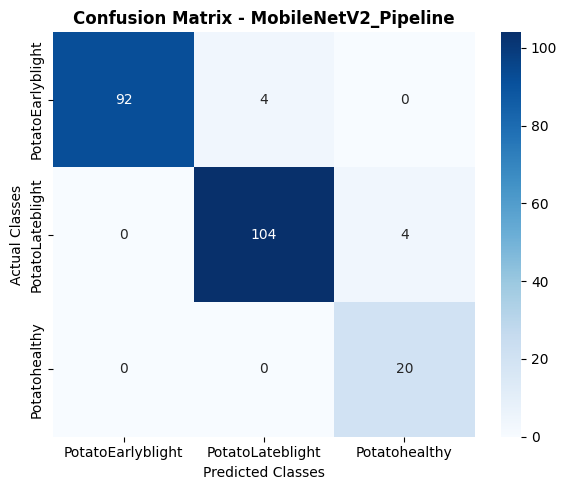

 ANALYTICAL EVALUATION: MobileNetV3_Pipeline
Overall Test Accuracy: 98.66%
Overall Test Loss: 0.0290

--- Detailed Classification Metrics ---
                   precision    recall  f1-score   support

PotatoEarlyblight       1.00      0.99      0.99        96
 PotatoLateblight       0.98      0.99      0.99       108
    Potatohealthy       0.95      0.95      0.95        20

         accuracy                           0.99       224
        macro avg       0.98      0.98      0.98       224
     weighted avg       0.99      0.99      0.99       224



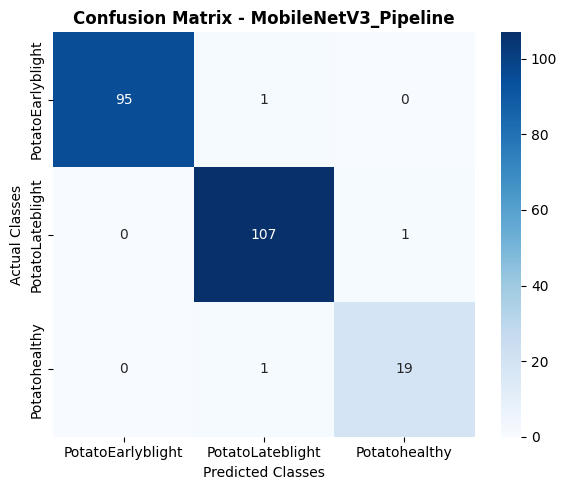

In [9]:
# Evaluation
# Analyze MobileNetV2 Performance
evaluate_and_analyze_model(mobilenet_model, test_ds, GLOBAL_CLASS_NAMES)

# Analyze MobileNetV3 Performance
evaluate_and_analyze_model(mobilenetv3_model, test_ds, GLOBAL_CLASS_NAMES)

 ROC-AUC CURVES: MobileNetV2_Pipeline


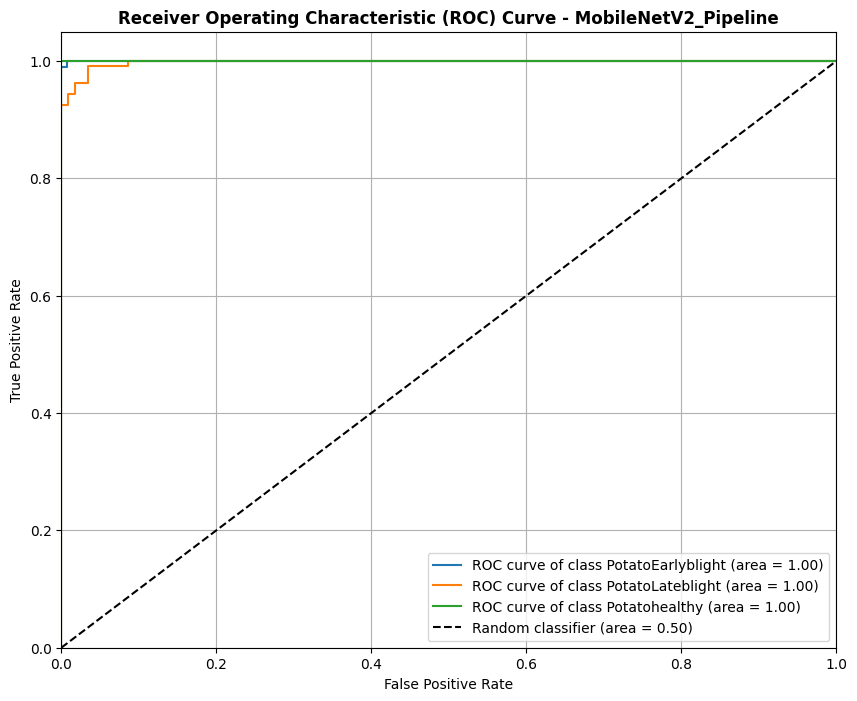

 ROC-AUC CURVES: MobileNetV3_Pipeline


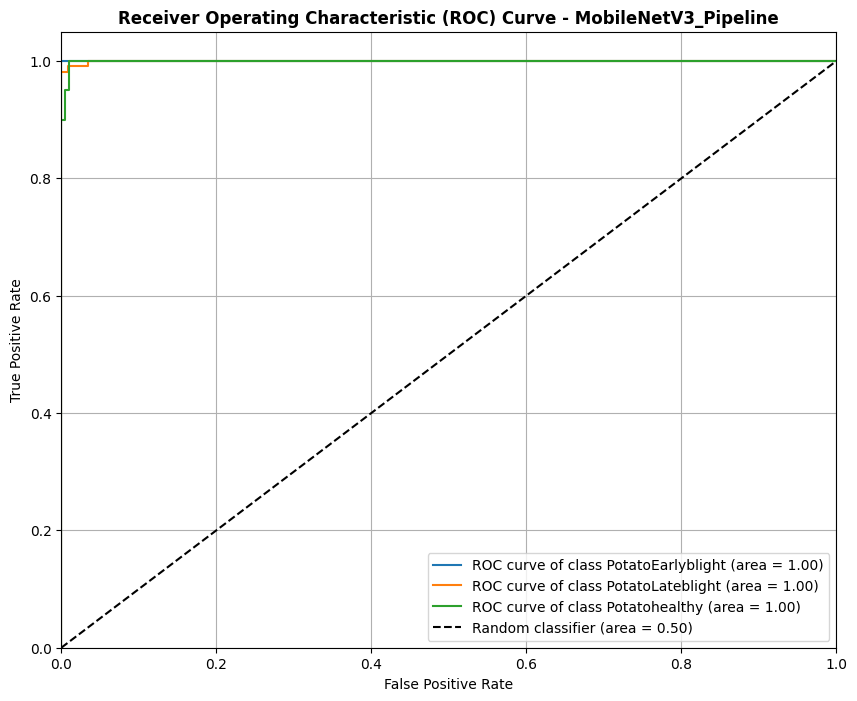

In [10]:
# plot the roc-auc curve for both

from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

def plot_roc_curve(model, test_dataset, class_names):

    print(f" ROC-AUC CURVES: {model.name}")

    y_true_labels = []
    y_pred_probs = []

    # Extract true labels and predicted probabilities from the dataset
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        y_true_labels.extend(labels.numpy())
        y_pred_probs.extend(preds)

    y_true_labels = np.array(y_true_labels)
    y_pred_probs = np.array(y_pred_probs)

    # Convert true labels to one-hot encoding for multi-class ROC curve
    n_classes = len(class_names)
    y_true_one_hot = to_categorical(y_true_labels, num_classes=n_classes)

    # Plot ROC curve for each class (one-vs-rest)
    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve of class {class_names[i]} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier (area = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model.name}', fontsize=12, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Analyze MobileNetV2 ROC-AUC
plot_roc_curve(mobilenet_model, test_ds, GLOBAL_CLASS_NAMES)

# Analyze MobileNetV3 ROC-AUC
plot_roc_curve(mobilenetv3_model, test_ds, GLOBAL_CLASS_NAMES)
